# 1. Khởi tạo và Nạp dữ liệu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os

# Thiết lập đường dẫn và load dữ liệu
base_dir = os.path.dirname(os.getcwd())
train_df = pd.read_csv(os.path.join(base_dir, 'data', 'preprocessed', 'train_data.csv'))
test_df = pd.read_csv(os.path.join(base_dir, 'data', 'preprocessed', 'test_data.csv'))

print(f"Dữ liệu huấn luyện: {train_df.shape}")
print(f"Dữ liệu kiểm tra: {test_df.shape}")

Dữ liệu huấn luyện: (7292, 14)
Dữ liệu kiểm tra: (1824, 14)


# 2. Feature Engineering
Thực hiện thiết kế mô hình tích hợp các kỹ thuật:
* **Đặc trưng đa thức (Polynomial):** Thêm biến diện tích bình phương để bắt lấy quan hệ phi tuyến.
* **Biến tương tác (Spatial Interaction):** Tạo sự kết hợp giữa diện tích và từng Quận cụ thể để mô hình hóa đơn giá riêng biệt cho mỗi khu vực.
* **Chọn subsets để xử lý đa cộng tuyến:** Loại bỏ cột 'thanh_pho' vì thông tin này đã được bao hàm trong biến 'quan'. Bên cạnh đó còn có `phong_tam` và `phong_ngu` cũng tương tự, tôi chỉ giữ lại cột `phong_tam`.

In [3]:
def prepare_features(df):
    temp_df = df.copy()
    
    # 1. Tạo biến Đa thức
    temp_df['dien_tich_poly2'] = temp_df['dien_tich_log'] ** 2
    
    # 2. CHỈ CHỌN các cột cần thiết, LOẠI BỎ cột thanh_pho để tránh đa cộng tuyến với Quận
    base_cols = ['dien_tich_log', 'dien_tich_poly2', 'phong_tam', 'so_tang', 'quan', 'phap_ly']
    
    # 3. Mã hóa One-Hot
    encoded_df = pd.get_dummies(temp_df[base_cols], drop_first=True)
    
    # 4. CHỈ tạo biến tương tác với Quận (Bỏ tương tác với Thành phố)
    district_cols = [col for col in encoded_df.columns if 'quan_' in col]
    for col in district_cols:
        encoded_df[f'inter_area_{col}'] = encoded_df['dien_tich_log'] * encoded_df[col]
        
    return encoded_df

# Thực thi trên cả 2 tập
X_train = prepare_features(train_df)
X_test = prepare_features(test_df)

# Đồng bộ hóa số lượng cột
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df['gia_log']
y_test_original = test_df['gia']

print(f"Tổng số đặc trưng sau khi xử lý tương tác: {X_train.shape[1]}")

Tổng số đặc trưng sau khi xử lý tương tác: 69


# 3. Huấn luyện mô hình và Metrics
Sử dụng thuật toán Hồi quy tuyến tính OLS. Danh sách các hệ số hồi quy dưới đây cho thấy trọng số của từng đặc trưng (diện tích, số tầng, pháp lý) và mức độ cộng thêm giá trị của từng Quận cụ thể lên biến mục tiêu `gia_log`.

In [4]:
# Khởi tạo và huấn luyện mô hình OLS
final_model = LinearRegression()
final_model.fit(X_train, y_train)

print("--- QUY TRÌNH HUẤN LUYỆN HOÀN TẤT ---")
print(f"Hệ số chặn (Intercept): {final_model.intercept_:.4f}")
for col, coef in zip(X_train.columns, final_model.coef_):
    print(f"  > {col}: {coef:.4f}")

--- QUY TRÌNH HUẤN LUYỆN HOÀN TẤT ---
Hệ số chặn (Intercept): -0.6008
  > dien_tich_log: 0.3509
  > dien_tich_poly2: 0.0394
  > phong_tam: 0.0301
  > so_tang: 0.0907
  > quan_Huyện Thanh Trì: -0.4204
  > quan_Quận 1: -0.0979
  > quan_Quận 10: -0.0096
  > quan_Quận 11: 0.5084
  > quan_Quận 12: 0.3984
  > quan_Quận 2: -1.3540
  > quan_Quận 3: 0.0784
  > quan_Quận 4: 0.4173
  > quan_Quận 5: 0.3225
  > quan_Quận 6: 0.4689
  > quan_Quận 7: 0.2688
  > quan_Quận 8: 0.8751
  > quan_Quận 9: 0.7397
  > quan_Quận Ba Đình: -1.2412
  > quan_Quận Bình Thạnh: 0.2832
  > quan_Quận Bình Tân: 0.4870
  > quan_Quận Bắc Từ Liêm: 0.3183
  > quan_Quận Cầu Giấy: -0.3241
  > quan_Quận Gò Vấp: 0.6358
  > quan_Quận Hai Bà Trưng: 0.1260
  > quan_Quận Hoàn Kiếm: 1.0600
  > quan_Quận Hoàng Mai: -0.7006
  > quan_Quận Hà Đông: 0.0772
  > quan_Quận Long Biên: -0.5123
  > quan_Quận Nam Từ Liêm: -1.1828
  > quan_Quận Phú Nhuận: 0.3400
  > quan_Quận Thanh Xuân: -1.1320
  > quan_Quận Tân Bình: 0.0472
  > quan_Quận Tân Phú

# 4. Đánh giá hiệu suất dự báo
Kết quả dự báo trên thang đo Logarit được chuyển đổi ngược về đơn vị gốc (Tỷ VNĐ) bằng hàm expm1 để tính toán các chỉ số sai số (MAE, MSE, RMSE) một cách thực tế để so sánh trực tiếp với các mô hình khác trong nhóm.

In [5]:
# Chạy model trên tập Test
y_pred_log = final_model.predict(X_test)

# Chuyển đổi ngược về đơn vị gốc (tỷ VND)
y_pred_original = np.expm1(y_pred_log)

# Tính Metrics
r2 = r2_score(test_df['gia_log'], y_pred_log)
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

print(f"{'Metric':<35} | {'Value':<15}")
print("-" * 55)
print(f"{'R-squared (R2)':<35} | {r2:.4f}")
print(f"{'Mean Absolute Error (MAE)':<35} | {mae:.4f} Tỷ")
print(f"{'Mean Squared Error (MSE)':<35} | {mse:.4f} Tỷ^2")
print(f"{'Root Mean Squared Error (RMSE)':<35} | {rmse:.4f} Tỷ")

Metric                              | Value          
-------------------------------------------------------
R-squared (R2)                      | 0.7502
Mean Absolute Error (MAE)           | 2.6138 Tỷ
Mean Squared Error (MSE)            | 23.7409 Tỷ^2
Root Mean Squared Error (RMSE)      | 4.8725 Tỷ


# 5. Trực quan hóa sai số (Residual Analysis)
* **Biểu đồ trái:** So sánh độ lệch giữa giá thực tế và dự báo so với đường lý tưởng (y=x).
* **Biểu đồ phải:** Kiểm tra phân phối của phần dư. Một phân phối chuẩn tập trung tại mốc 0 cho thấy mô hình hoạt động ổn định và tin cậy.

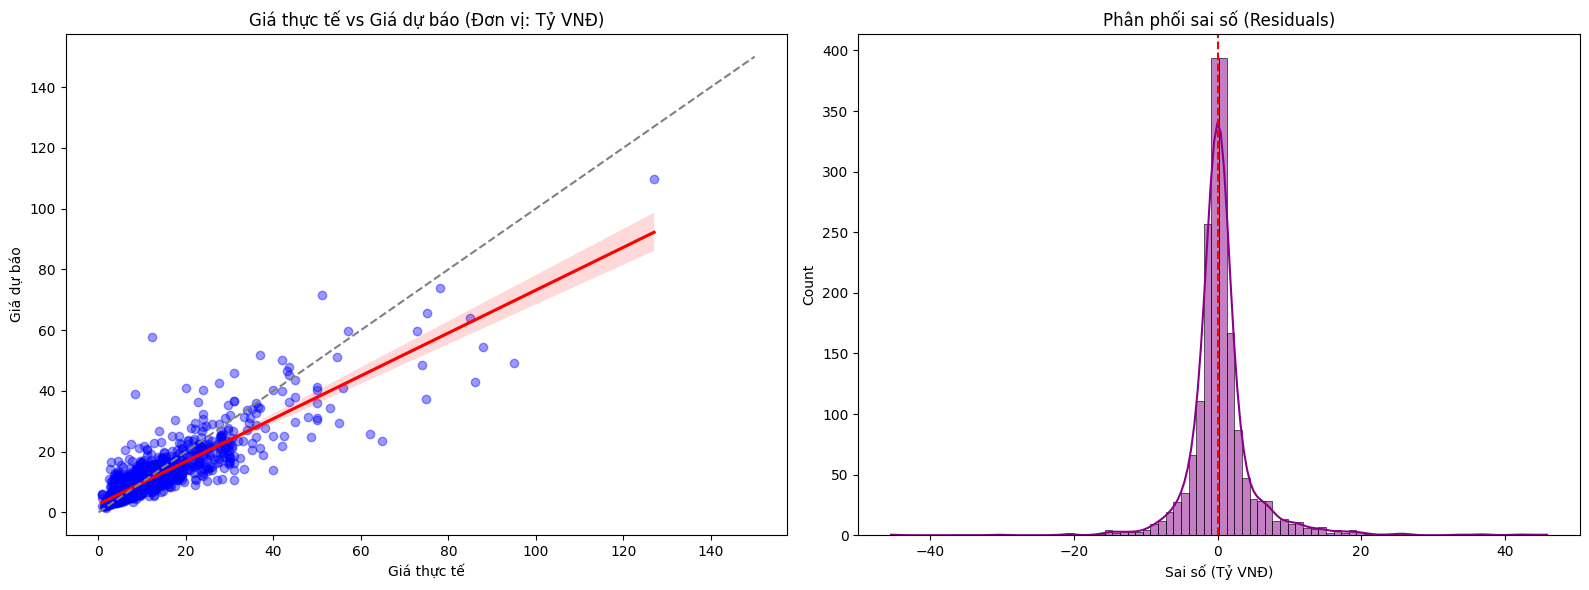

In [6]:
plt.figure(figsize=(16, 6))

# Biểu đồ 1: Thực tế vs Dự đoán
plt.subplot(1, 2, 1)
sns.regplot(x=y_test_original, y=y_pred_original, scatter_kws={'alpha':0.4, 'color':'blue'}, line_kws={'color':'red'})
plt.plot([0, 150], [0, 150], '--', color='gray') # Đường lý tưởng
plt.title("Giá thực tế vs Giá dự báo (Đơn vị: Tỷ VNĐ)")
plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự báo")

# Biểu đồ 2: Phân phối phần dư (Residuals)
plt.subplot(1, 2, 2)
residuals = y_test_original - y_pred_original
sns.histplot(residuals, kde=True, color='darkmagenta')
plt.axvline(0, color='red', linestyle='--')
plt.title("Phân phối sai số (Residuals)")
plt.xlabel("Sai số (Tỷ VNĐ)")

plt.tight_layout()
plt.show()

# 6. Giải thích kết quả và góc nhìn sâu sắc (Interpretation and Insights)


C:\Users\Khanh Linh\AppData\Local\Temp\ipykernel_29028\3722105179.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_coefs, palette='viridis')


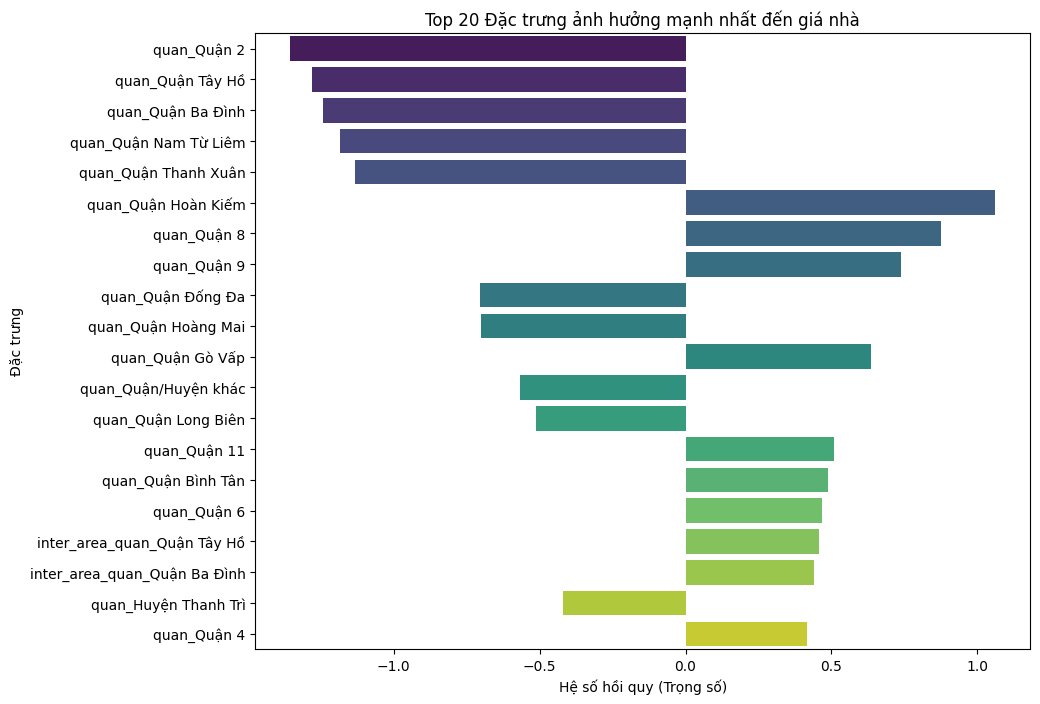

In [7]:
# Lấy các hệ số từ mô hình
coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': final_model.coef_
})

# Sắp xếp theo mức độ ảnh hưởng (trị tuyệt đối)
coefs['Abs_Coef'] = coefs['Coefficient'].abs()
top_coefs = coefs.sort_values(by='Abs_Coef', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=top_coefs, palette='viridis')
plt.title("Top 20 Đặc trưng ảnh hưởng mạnh nhất đến giá nhà")
plt.xlabel("Hệ số hồi quy (Trọng số)")
plt.ylabel("Đặc trưng")
plt.show()



### 6.1 Giải thích hệ số hồi quy (Interpreting Coefficients)

Dựa trên biểu đồ trọng số của mô hình hồi quy, chúng ta có thể phân tích mức độ tác động của các yếu tố (đặc trưng) lên giá trị của bất động sản. Do mô hình sử dụng thang đo Logarithm cho biến mục tiêu, các hệ số này phản ánh tỷ lệ phần trăm thay đổi của giá nhà khi các biến số thay đổi.

#### 1. Các yếu tố thúc đẩy tăng giá mạnh nhất (Hệ số dương)
*   **Vị trí trung tâm (Quận Hoàn Kiếm):** Đây là đặc trưng có tác động dương mạnh nhất (hệ số ~1.06). Trong điều kiện các yếu tố khác tương đương, bất động sản tại Quận Hoàn Kiếm có giá trị cao vượt trội so với các khu vực khác. Điều này hoàn toàn phù hợp với thực tế thị trường khi quỹ đất tại lõi thủ đô vô cùng khan hiếm và mang giá trị thương mại cao.
*   **Các khu vực đang phát triển nhanh (Quận 8, Quận 9, Quận Gò Vấp):** Các quận này cũng cho thấy hệ số dương lớn (từ 0.6 đến 0.9). Điều này phản ánh xu hướng dịch chuyển đầu tư và sự cải thiện hạ tầng mạnh mẽ tại các khu vực này trong thời gian qua, đẩy mặt bằng giá lên cao.
*   **Biến tương tác Diện tích - Vị trí (Interaction Terms):** Các biến như `inter_area_quan_Quận Tây Hồ` và `inter_area_quan_Quận Ba Đình` có hệ số dương đáng kể. 
    *   **Insight:** Điều này có nghĩa là tại Tây Hồ hay Ba Đình, giá trị căn nhà không chỉ tăng theo diện tích mà còn tăng với **tỷ lệ cao hơn** so với các quận khác. Diện tích càng lớn tại các khu vực thượng lưu này thì giá trị cộng thêm càng khổng lồ (hiệu ứng đất vàng).

#### 2. Các khu vực có hệ số cơ sở âm (Hệ số âm)
*   **Quận 2, Quận Tây Hồ, Quận Ba Đình (Hệ số cơ sở):** Lưu ý rằng các quận này có hệ số cơ sở âm (từ -1.0 đến -1.35) trong biểu đồ. 
    *   **Giải thích:** Đây không phải là giá nhà ở đây rẻ, mà vì chúng ta đã tách riêng phần **biến tương tác với diện tích** ở trên. Hệ số âm này cho thấy nếu diện tích nhà rất nhỏ (tiến về 0), giá trị cơ sở sẽ thấp, nhưng khi diện tích tăng lên, giá trị sẽ được bù đắp và tăng vọt nhờ vào các biến tương tác dương đã phân tích ở mục 1.
*   **Huyện Thanh Trì và các khu vực ngoại ô:** Hệ số âm ở các khu vực này phản ánh đúng thực tế là giá trị bất động sản tại vùng ven thấp hơn đáng kể so với các quận nội thành.

#### 3. Tổng kết về tầm quan trọng của các yếu tố
*   **Vị trí là biến số quan trọng nhất:** 18/20 đặc trưng ảnh hưởng mạnh nhất đều liên quan đến địa giới hành chính (Quận). Điều này khẳng định trong định giá bất động sản, vị trí (location) chiếm ưu thế tuyệt đối so với các yếu tố vật lý đơn thuần.
*   **Sự phân hóa theo khu vực:** Mô hình đã nắm bắt được sự khác biệt về đặc thù giá giữa các quận. Cùng một diện tích, nhưng nếu dịch chuyển từ một quận có hệ số âm (ngoại ô) sang quận có hệ số dương lớn (trung tâm), giá trị tài sản có thể tăng theo cấp số nhân.



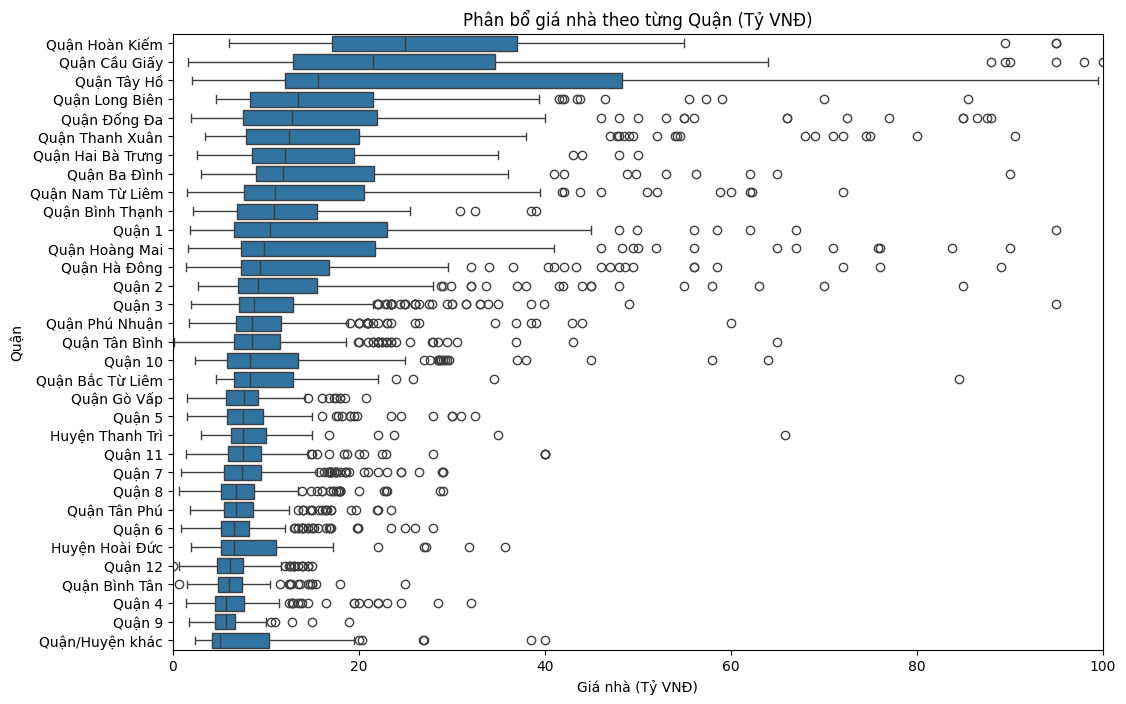

In [8]:
plt.figure(figsize=(12, 8))
# Sắp xếp các quận theo giá trung bình
order_districts = train_df.groupby('quan')['gia'].median().sort_values(ascending=False).index
sns.boxplot(x='gia', y='quan', data=train_df, order=order_districts)
plt.title("Phân bổ giá nhà theo từng Quận (Tỷ VNĐ)")
plt.xlabel("Giá nhà (Tỷ VNĐ)")
plt.ylabel("Quận")
plt.xlim(0, 100) 
plt.show()



### 6.2 Yếu tố cốt lõi (Core Factors) - Vai trò của Vị trí địa lý

Biểu đồ Boxplot thể hiện sự phân bổ giá nhà (đơn vị: Tỷ VNĐ) theo từng Quận cung cấp cái nhìn trực quan về lý do tại sao **Vị trí** là yếu tố cốt lõi, quyết định phần lớn giá trị của bất động sản trong bộ dữ liệu.

#### 1. Sự phân hóa đẳng cấp giữa các khu vực
*   **Nhóm dẫn đầu thị trường (Hoàn Kiếm, Cầu Giấy, Tây Hồ):** Đây là các quận có trung vị (median) giá nhà cao nhất, dao động từ 15 đến gần 30 tỷ VNĐ. 
    *   **Quận Hoàn Kiếm** không chỉ có mức giá trung bình cao nhất mà còn có dải giá (Interquartile Range - IQR) cực rộng, cho thấy sự khan hiếm và đắt đỏ đặc trưng của khu vực lõi lịch sử.
    *   **Quận Cầu Giấy và Tây Hồ** bám sát nút, phản ánh giá trị của các khu đô thị mới, hiện đại và khu vực có cảnh quan (hồ Tây) đắc địa.
*   **Nhóm phổ thông (Quận 12, Bình Tân, Quận 9, Quận 4):** Các khu vực này có mức giá tập trung chủ yếu dưới 10 tỷ VNĐ. Dải giá ở đây hẹp hơn, cho thấy thị trường ở các khu vực này ổn định hơn và phù hợp với đại đa số người mua nhà có nhu cầu ở thực.

#### 2. Độ biến động và các giá trị ngoại lai (Outliers)
*   **Tính biến động cao ở quận "VIP":** Các quận nằm ở phía trên của biểu đồ (như Cầu Giấy, Tây Hồ, Long Biên) có phần "râu" (whiskers) rất dài và nhiều điểm ngoại lai (chấm tròn) kéo dài tới mốc 100 tỷ VNĐ.
    *   **Insight:** Điều này cho thấy tại các quận này, vị trí cụ thể (ví dụ: nhà mặt phố lớn so với nhà trong hẻm nhỏ) tạo ra sự chênh lệch giá trị khổng lồ, lên tới hàng chục tỷ đồng dù có thể cùng một diện tích.
*   **Sự xuất hiện của các "Siêu biệt thự":** Hầu như quận nào cũng xuất hiện các điểm ngoại lai phía bên phải. Điều này phản ánh sự tồn tại của những bất động sản đặc biệt (biệt thự sang trọng, nhà mặt tiền kinh doanh đắc địa) có giá trị vượt xa mặt bằng chung của khu vực đó.

#### 3. Kết luận về yếu tố quyết định
Từ biểu đồ, chúng ta có thể khẳng định: **Vị trí địa lý (Quận) là yếu tố "quyền lực" nhất.**
*   Vị trí quyết định "điểm khởi đầu" của giá nhà: Một căn nhà "bình thường" ở Hoàn Kiếm đã có giá khởi điểm cao hơn đa số nhà ở các quận ngoại thành.
*   Vị trí quyết định tiềm năng tăng giá: Các quận có dải giá rộng thường là những nơi có hạ tầng đang phát triển mạnh hoặc có giá trị thương mại cao, khiến giá nhà biến động mạnh và có nhiều cơ hội tạo ra giá trị thặng dư lớn.



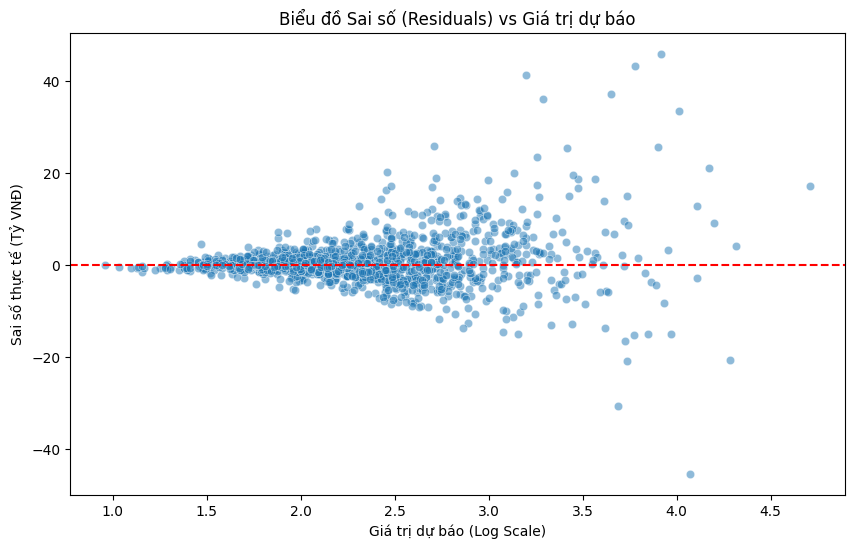

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_log, y=y_test_original - y_pred_original, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Biểu đồ Sai số (Residuals) vs Giá trị dự báo")
plt.xlabel("Giá trị dự báo (Log Scale)")
plt.ylabel("Sai số thực tế (Tỷ VNĐ)")
plt.show()



### 6.3 Những phát hiện (Insights) từ mô hình và Đánh giá sai số

Biểu đồ **Sai số (Residuals) vs Giá trị dự báo** là một công cụ quan trọng để kiểm tra tính ổn định của mô hình và rút ra các quy luật thị trường ngầm định:

#### 1. Hiện tượng "Phương sai thay đổi" (Heteroscedasticity)
*   Quan sát biểu đồ, ta thấy hình dáng của các điểm dữ liệu tạo thành một **"hình cái phễu" (fan-shape)** mở rộng dần từ trái sang phải.
*   **Giải thích:** Ở phân khúc giá thấp (giá trị dự báo log từ 1.0 đến 2.0), các sai số tập trung rất sát đường 0. Tuy nhiên, khi giá trị nhà tăng lên, độ lệch (sai số) giữa giá dự báo và giá thực tế cũng tăng mạnh theo.
*   **Insight:** Mô hình hoạt động cực kỳ chính xác và ổn định đối với các bất động sản giá rẻ và tầm trung (phân khúc phổ thông). Tuy nhiên, đối với các bất động sản giá trị cao (phân khúc cao cấp), mô hình trở nên "kém chắc chắn" hơn.

#### 2. Giới hạn của mô hình ở phân khúc cao cấp
*   Tại khu vực bên phải biểu đồ (giá trị dự báo cao), xuất hiện nhiều điểm có sai số cực lớn, lên đến **+40 tỷ** hoặc **-40 tỷ VNĐ**. 
*   **Insight:** Điều này củng cố giả thuyết rằng giá trị của các bất động sản hạng sang (Luxury) không chỉ đơn thuần tính bằng diện tích hay vị trí quận. Chúng còn bị chi phối mạnh mẽ bởi các yếu tố "vô hình" mà dữ liệu hiện tại chưa bao hàm hết như:
    *   Thiết kế nội thất xa xỉ.
    *   Giá trị phong thủy đặc biệt.
    *   Lợi thế mặt tiền kinh doanh (vỉa hè rộng, lô góc).
    *   Sự kỳ vọng hoặc "thổi giá" của chủ nhà/môi giới ở các căn nhà đặc biệt.

#### 3. Tính khách quan của mô hình
*   Dù phương sai thay đổi, nhưng các điểm sai số vẫn phân bổ khá đều xung quanh đường **0 (đường màu đỏ)**. 
*   **Insight:** Điều này cho thấy mô hình không bị thiên kiến (bias) quá nặng về một phía (không liên tục dự báo quá cao hay quá thấp). Sai số lớn ở phân khúc cao cấp chủ yếu là do sự biến động tự nhiên và sự thiếu hụt đặc trưng của dữ liệu, chứ không phải do lỗi cấu trúc của thuật toán hồi quy.

#### 4. Kết luận cho chiến lược sử dụng mô hình
*   Mô hình này là công cụ định giá **đáng tin cậy cho 80% thị trường** (phân khúc nhà dân dụng phổ thông dưới 40 tỷ).
*   Đối với các bất động sản siêu sang hoặc các trường hợp đặc biệt (các điểm ngoại lai xa đường 0), mô hình nên được sử dụng như một **"mức giá tham chiếu cơ bản"**, và cần kết hợp thêm sự thẩm định trực tiếp từ chuyên gia để có kết quả chính xác nhất.



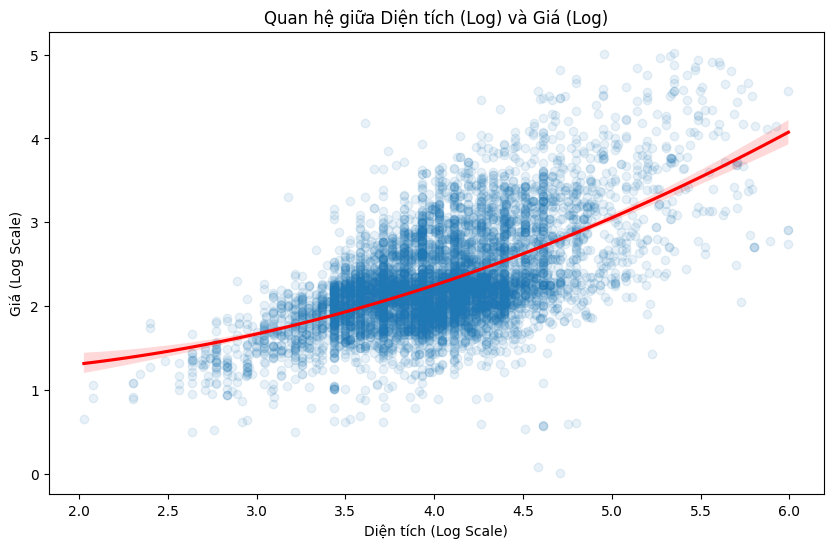

In [10]:
plt.figure(figsize=(10, 6))
sns.regplot(x='dien_tich_log', y='gia_log', data=train_df, scatter_kws={'alpha':0.1}, line_kws={'color':'red'}, order=2)
plt.title("Quan hệ giữa Diện tích (Log) và Giá (Log)")
plt.xlabel("Diện tích (Log Scale)")
plt.ylabel("Giá (Log Scale)")
plt.show()



### 6.4 Yếu tố cốt lõi (Core Factors) - Tác động phi tuyến của Diện tích

Bên cạnh vị trí, diện tích là biến số vật lý có tác động trực tiếp và mạnh mẽ nhất đến giá trị bất động sản. Biểu đồ phân tán (Scatter plot) kết hợp đường hồi quy bậc 2 (Polynomial) cho thấy những quy luật quan trọng:

#### 1. Mối tương quan thuận mạnh mẽ (Strong Positive Correlation)
*   Quan sát biểu đồ trên thang đo Log-Log, ta thấy các điểm dữ liệu phân bổ theo một xu hướng đi lên rất rõ ràng. 
*   **Insight:** Điều này khẳng định diện tích là "xương sống" của giá trị bất động sản. Diện tích tăng 1% thì giá nhà trung bình sẽ tăng theo một tỷ lệ tương ứng (hệ số co giãn). Hầu hết các giao dịch tập trung dày đặc ở dải diện tích trung bình (log từ 3.5 đến 4.5), phản ánh phân khúc nhà ở phổ thông.

#### 2. Tính phi tuyến và "Giá trị cộng thêm" của diện tích lớn
*   Đường hồi quy màu đỏ có xu hướng **cong nhẹ lên phía trên** (không phải là một đường thẳng tắp). 
*   **Giải thích:** Việc sử dụng biến đa thức (`dien_tich_poly2`) trong mô hình là hoàn toàn đúng đắn. Trong thực tế bất động sản dân dụng, những lô đất có diện tích lớn thường cho phép xây dựng các công trình đa năng (kết hợp kinh doanh, cho thuê) hoặc có giá trị sử dụng cao hơn hẳn.
*   **Insight:** Giá nhà không tăng tuyến tính theo diện tích. Khi diện tích đạt đến một ngưỡng nhất định, mỗi mét vuông cộng thêm sẽ mang lại giá trị thặng dư cao hơn so với các mảnh đất nhỏ (Size Premium). Điều này đặc biệt đúng tại các khu vực đô thị đông đúc, nơi các quỹ đất diện tích lớn rất khan hiếm.

#### 3. Sự phân hóa về giá ở cùng một diện tích
*   Tại cùng một cột diện tích trên trục X, các điểm dữ liệu trải dài theo trục Y (giá) với biên độ khá rộng.
*   **Insight:** Điều này một lần nữa minh chứng rằng: **Dù diện tích là yếu tố cốt lõi, nhưng nó không quyết định tất cả.** Sự chênh lệch giá tại cùng một mức diện tích chính là do tác động của **Vị trí (Quận)** và các đặc trưng định tính khác (pháp lý, số tầng) mà chúng ta đã phân tích ở các biểu đồ trước.

#### 4. Hiện tượng phân tán ở nhóm diện tích cực lớn
*   Ở cuối biểu đồ bên phải (nhóm diện tích lớn nhất), các điểm dữ liệu phân tán rộng hơn.
*   **Insight:** Phân khúc bất động sản diện tích lớn (biệt thự, tòa nhà văn phòng) có quy luật định giá phức tạp và cá nhân hóa hơn, chịu ảnh hưởng mạnh bởi mục tiêu đầu tư thay vì chỉ là nhu cầu ở thông thường.



# 7. Đánh giá kết luận

1. **Hiệu suất dự báo:** Mô hình đạt R2 = 0.7502 và MAE = 2.6 tỷ VNĐ. Đây là kết quả khả quan hơn model baseline, cho thấy mô hình nắm bắt được quy luật định giá của 75% thị trường bất động sản dân dụng trong bộ dữ liệu.

2. **Phân tích giới hạn của chỉ số R2:** 
Tôi nghĩ chỉ số R2 khó có thể đẩy cao hơn sau nhiều lần thử nghiệm do những rào cản từ đặc thù dữ liệu:
* **Thiếu  một số đặc trưng then chốt:** Các yếu tố cực kỳ quan trọng như "nhà mặt tiền", "độ rộng hẻm", "hướng nhà" hay "chất lượng nội thất" xuất hiện không đồng nhất trong tin đăng thô, khiến nhóm không thể trích xuất toàn diện cho toàn bộ 9.116 mẫu. Từ đó, khiến việc nắm bắt quy luật giá nhà từ bộ dữ liệu trên khó đạt độ hoàn hảo cao hơn.
* **Biến số định tính:** Giá bất động sản thực tế còn bị chi phối bởi các yếu tố phong thủy, tâm lý chủ nhà và tình trạng xuống cấp của công trình - những thông tin mà các biến số vật lý hiện có không thể bao hàm hết. Hay thậm chí là có những nhà bị rao bán với giá 'ảo', khiến khó nắm được quy luật hơn.

3. **Đánh giá trực quan qua biểu đồ:**
* **Giá thực tế vs Dự báo:** Các điểm dữ liệu bám sát đường lý tưởng (y=x) ở phân khúc nhà phổ thông (dưới 40 tỷ). Với các bất động sản giá trị cao (>60 tỷ), đường hồi quy thực tế (màu đỏ) có xu hướng lệch xuống dưới, cho thấy mô hình dự báo thấp hơn thực tế.
* **Phân phối phần dư:** Sai số tập trung nhiều tại mốc 0 và tạo thành hình quả chuông đối xứng. Điều này cho thấy mô hình đạt độ ổn định tương đối cao, hoàn toàn có thể tin cậy trong phạm vi các đặc trưng hiện có. Nhưng trong đó, cũng có một vài điểm dữ liệu dự đoán có phần dư lớn, có thể là nhiễu hoặc những trường hợp đặc biệt mà mô hình chưa nắm bắt được quy luật do chưa khai thác đủ đặc trưng.

# 8. Đóng gói model đưa lên interface

In [11]:
import joblib

# 1. Lưu mô hình chính
joblib.dump(final_model, 'model_bat_dong_san.pkl')

# 2. Lưu danh sách các cột của X_train (Cực kỳ quan trọng để khớp One-Hot Encoding)
model_columns = list(X_train.columns)
joblib.dump(model_columns, 'model_columns.pkl')

print("Đã đóng gói xong: 'model_bat_dong_san.pkl' và 'model_columns.pkl'")

Đã đóng gói xong: 'model_bat_dong_san.pkl' và 'model_columns.pkl'
